# Music Energy / Stress Analysis

Downloads the first **N songs** from a public-domain YouTube playlist, then visualises
how the energy and 'stress' of each song evolve over time.

**Stress score** = weighted blend of three features:

| Feature | Weight | What it captures |
|---|---|---|
| RMS energy | 50 % | Loudness / power |
| Spectral centroid | 25 % | Brightness (more treble → higher) |
| Onset strength | 25 % | Rhythmic density (attacks per second) |

The smoothed curve lets you clearly see **intro → build-up → chorus → outro** transitions.

In [1]:
# Run once to install all dependencies into this kernel's Python
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                       'yt-dlp', 'librosa', 'soundfile', '-q'])
print('Dependencies ready.')

Dependencies ready.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.ndimage import uniform_filter1d
from pathlib import Path

print('Libraries loaded.')

Libraries loaded.


## Configuration

Adjust the constants below before running anything else.

In [3]:
import re

PLAYLIST_URL = 'https://www.youtube.com/playlist?list=PL7DA3D097D6FDBC02'
N_SONGS      = 40       # how many songs to grab from the playlist

# Folder is named after the playlist ID — swap the URL and you get a separate folder automatically
_playlist_id = re.search(r'[?&]list=([^&]+)', PLAYLIST_URL).group(1)
DOWNLOAD_DIR = Path('downloads') / _playlist_id

SR           = 22050    # sample rate used by librosa
HOP_LENGTH   = 512      # frame step  ≈ 23 ms
SMOOTH_SEC   = 5        # rolling-window size for the macro stress curve (seconds)

print(f'Playlist ID : {_playlist_id}')
print(f'Download dir: {DOWNLOAD_DIR}')

Playlist ID : PL7DA3D097D6FDBC02
Download dir: downloads/PL7DA3D097D6FDBC02


## Download

> **Run this cell only when you are ready to download.**  
> Songs are saved as MP3 files inside `downloads/<playlist-id>/`.  
> Re-running is safe — already-downloaded tracks are skipped automatically.

In [4]:
import yt_dlp

DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)
_archive = str(DOWNLOAD_DIR / '.yt-dlp-archive')  # tracks downloaded IDs → skip on re-run

ydl_opts = {
    'format': 'bestaudio/best',
    'outtmpl': str(DOWNLOAD_DIR / '%(playlist_index)02d_%(title)s.%(ext)s'),
    'postprocessors': [{
        'key': 'FFmpegExtractAudio',
        'preferredcodec': 'mp3',
        'preferredquality': '192',
    }],
    'playlistend': N_SONGS,
    'quiet': False,
    'ignoreerrors': True,
    'nooverwrites': True,
    'download_archive': _archive,
}

with yt_dlp.YoutubeDL(ydl_opts) as ydl:
    ydl.download([PLAYLIST_URL])

files = sorted(DOWNLOAD_DIR.glob('*.mp3'))
print(f'\n{len(files)} file(s) in {DOWNLOAD_DIR}:')
for f in files:
    print(' ', f.name)

[youtube:tab] Extracting URL: https://www.youtube.com/playlist?list=PL7DA3D097D6FDBC02
[youtube:tab] PL7DA3D097D6FDBC02: Downloading webpage
[youtube:tab] PL7DA3D097D6FDBC02: Redownloading playlist API JSON with unavailable videos
[download] Downloading playlist: 90's Hits - Greatest 1990's Music Hits (Best 90’s Songs Playlist)
[youtube:tab] Playlist 90's Hits - Greatest 1990's Music Hits (Best 90’s Songs Playlist): Downloading 40 items of 150
[download] QNJL6nfu__Q: Michael Jackson - They Don't Care About Us has already been recorded in the archive
[download] XFkzRNyygfk: Radiohead - Creep has already been recorded in the archive
[download] 6NXnxTNIWkc: 4 Non Blondes - What's Up (Official Music Video) has already been recorded in the archive
[download] SQCSxqScSVQ: Coolio - Gangsta's Paradise (feat. L.V.) [Official 4K Music Video] has already been recorded in the archive
[download] Y0pdQU87dc8: Bryan Adams - (Everything I Do) I Do It For You has already been recorded in the archive
[d

## Analysis

1. Run **List files** to see what was downloaded.
2. Set `FILE_IDX` to the song you want to analyse.
3. Run the remaining cells in order.

In [5]:
audio_files = sorted(DOWNLOAD_DIR.glob('*.mp3'))
if not audio_files:
    print(f'No MP3 files found in {DOWNLOAD_DIR} — run the Download cell first.')
else:
    for i, f in enumerate(audio_files):
        print(f'[{i}]  {f.name}')

[0]  01_Michael Jackson - They Don't Care About Us.mp3
[1]  02_Radiohead - Creep.mp3
[2]  03_4 Non Blondes - What's Up (Official Music Video).mp3
[3]  04_Coolio - Gangsta's Paradise (feat. L.V.) [Official 4K Music Video].mp3
[4]  05_Bryan Adams - (Everything I Do) I Do It For You.mp3
[5]  06_Michael Jackson - Earth Song (Official Video).mp3
[6]  07_Nirvana - Smells Like Teen Spirit (Official Music Video).mp3
[7]  08_Black or White (Single Version).mp3
[8]  09_The Cranberries - Zombie (Official Music Video).mp3
[9]  10_Haddaway  -  Lift Your Head Up.mp3
[10]  11_Whitney Houston - I Will Always Love You (Official 4K Video).mp3
[11]  12_Metallica - Nothing Else Matters (Official Music Video).mp3
[12]  13_Britney Spears - ...Baby One More Time (Official Video).mp3
[13]  14_The Verve - Bitter Sweet Symphony.mp3
[14]  15_Michael Jackson - You Are Not Alone (Official Video).mp3
[15]  16_Fugees - Killing Me Softly With His Song (Official Video).mp3
[16]  17_No Doubt - Don't Speak (Official 4K 

In [6]:
FILE_IDX = 0  # ← change to pick a different song

audio_path = audio_files[FILE_IDX]
print(f'Loading: {audio_path.name}')

y, sr = librosa.load(str(audio_path), sr=SR, mono=True)
duration = len(y) / sr
print(f'Duration : {duration:.1f} s  ({duration / 60:.2f} min)')
print(f'Samples  : {len(y):,}')

Loading: 01_Michael Jackson - They Don't Care About Us.mp3
Duration : 281.6 s  (4.69 min)
Samples  : 6,208,513


### Feature extraction

Each feature is computed per *frame* (~23 ms), then the stress score is smoothed
over a `SMOOTH_SEC`-wide rolling window to expose the macro song structure.

In [7]:
def compute_features(fpath, sr=SR, hop_length=HOP_LENGTH):
    """Return (rms, centroid, onset_env, times) — loads from .npz cache if available."""
    cache = fpath.with_suffix('.features.npz')
    if cache.exists():
        d = np.load(cache)
        return d['rms'], d['centroid'], d['onset_env'], d['times']
    y, _ = librosa.load(str(fpath), sr=sr, mono=True)
    rms       = librosa.feature.rms(y=y, hop_length=hop_length)[0]
    centroid  = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=hop_length)[0]
    onset_env = librosa.onset.onset_strength(y=y, sr=sr, hop_length=hop_length)
    times     = librosa.times_like(rms, sr=sr, hop_length=hop_length)
    np.savez(cache, rms=rms, centroid=centroid, onset_env=onset_env, times=times)
    return rms, centroid, onset_env, times

In [8]:
def norm01(x):
    lo, hi = x.min(), x.max()
    return (x - lo) / (hi - lo + 1e-8)

_cached = audio_path.with_suffix('.features.npz').exists()
rms, centroid, onset_env, times = compute_features(audio_path)
print(f'Features {"loaded from cache" if _cached else "computed and cached"}  |  {len(times):,} frames')

# Weighted stress score (raw, per-frame)
stress_raw = (
    0.50 * norm01(rms) +
    0.25 * norm01(centroid) +
    0.25 * norm01(onset_env)
)

# Smooth → macro song structure
smooth_frames = int(SMOOTH_SEC * SR / HOP_LENGTH)
stress_smooth = uniform_filter1d(stress_raw, size=smooth_frames)
stress_smooth = norm01(stress_smooth)

print(f'Stress score ready  |  smoothing window = {smooth_frames} frames ({SMOOTH_SEC} s)')

Features loaded from cache  |  12,127 frames
Stress score ready  |  smoothing window = 215 frames (5 s)


### Visualisation

Three panels:
- **Top** – stress time series (raw + smoothed)
- **Middle** – individual feature breakdown
- **Bottom** – mel spectrogram (frequency content over time)

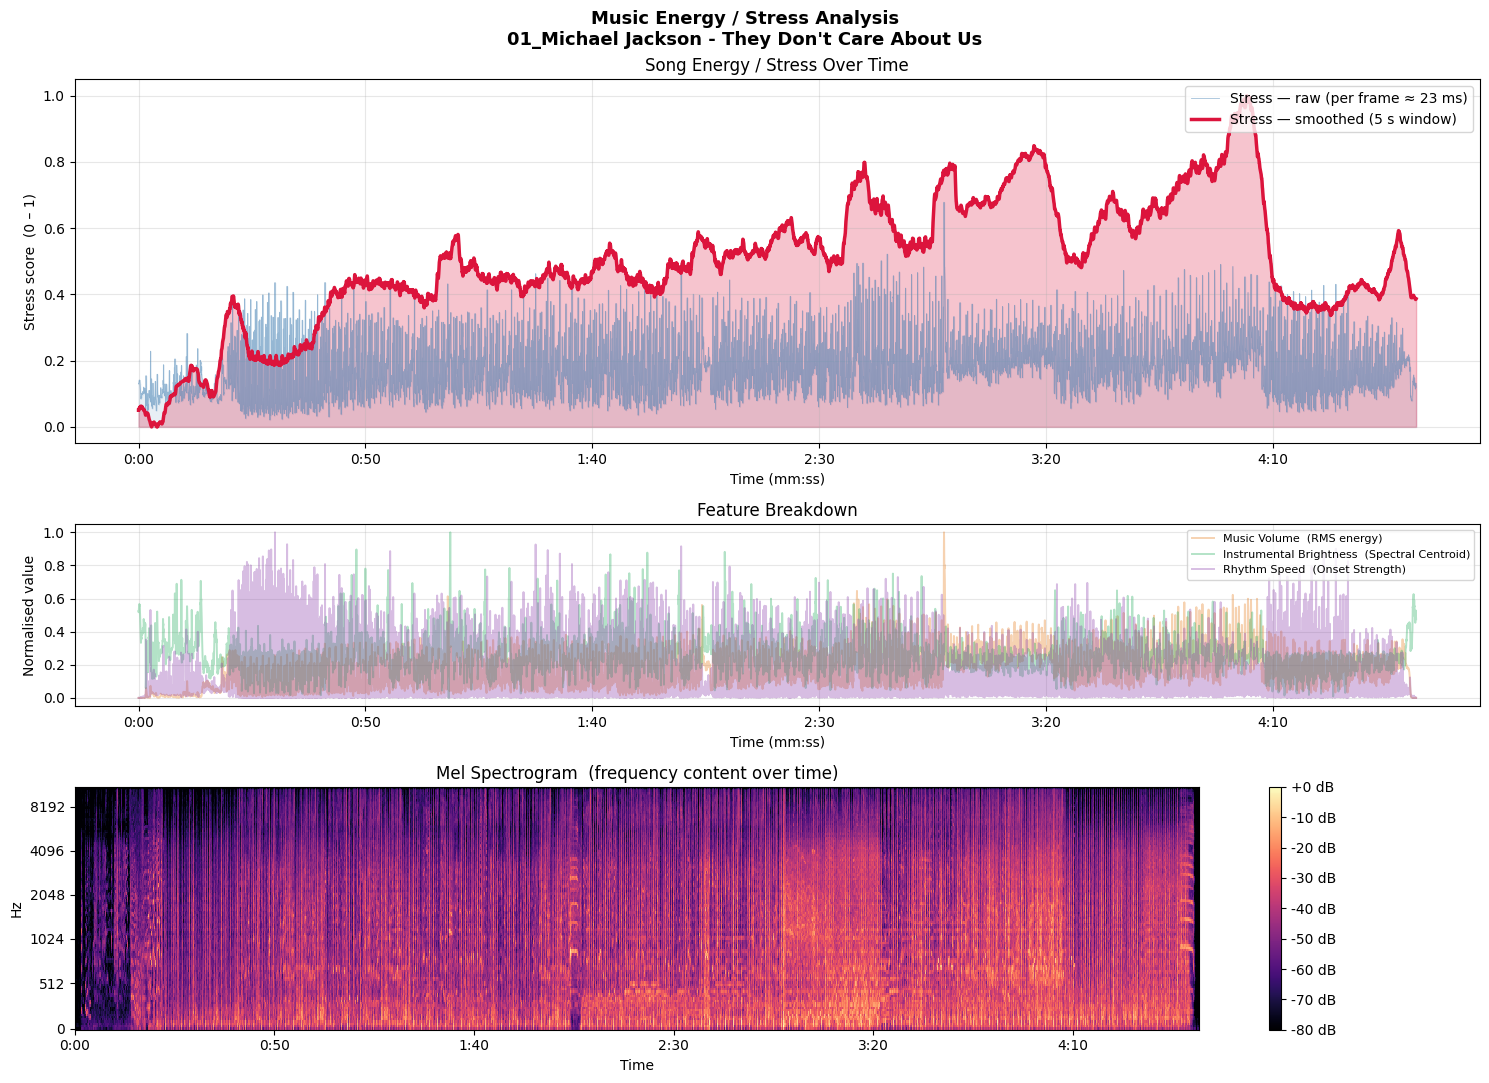

Plot saved → downloads/PL7DA3D097D6FDBC02/01_Michael Jackson - They Don't Care About Us_stress.png


In [9]:
def fmt_time(x, _):
    m, s = divmod(int(x), 60)
    return f'{m}:{s:02d}'

fig, axes = plt.subplots(
    3, 1, figsize=(15, 11),
    gridspec_kw={'height_ratios': [3, 1.5, 2]}
)
fig.suptitle(
    f'Music Energy / Stress Analysis\n{audio_path.stem}',
    fontsize=13, fontweight='bold'
)

# ── Panel 1: stress ──────────────────────────────────────────────────────────
ax1 = axes[0]
ax1.fill_between(times, stress_raw,    alpha=0.12, color='steelblue')
ax1.fill_between(times, stress_smooth, alpha=0.25, color='crimson')
ax1.plot(times, stress_raw,    color='steelblue', linewidth=0.6, alpha=0.5,
         label='Stress — raw (per frame ≈ 23 ms)')
ax1.plot(times, stress_smooth, color='crimson',   linewidth=2.5,
         label=f'Stress — smoothed ({SMOOTH_SEC} s window)')
ax1.set_ylabel('Stress score  (0 – 1)')
ax1.set_ylim(-0.05, 1.05)
ax1.legend(loc='upper right')
ax1.set_title('Song Energy / Stress Over Time')
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(fmt_time))
ax1.set_xlabel('Time (mm:ss)')
ax1.grid(True, alpha=0.3)

# ── Panel 2: feature breakdown ────────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(times, norm01(rms),       color='#e67e22', linewidth=1.4, alpha=0.35,
         label='Music Volume  (RMS energy)')
ax2.plot(times, norm01(centroid),  color='#27ae60', linewidth=1.4, alpha=0.35,
         label='Instrumental Brightness  (Spectral Centroid)')
ax2.plot(times, norm01(onset_env), color='#8e44ad', linewidth=1.4, alpha=0.35,
         label='Rhythm Speed  (Onset Strength)')
ax2.set_ylabel('Normalised value')
ax2.set_ylim(-0.05, 1.05)
ax2.legend(loc='upper right', fontsize=8)
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(fmt_time))
ax2.set_xlabel('Time (mm:ss)')
ax2.grid(True, alpha=0.3)
ax2.set_title('Feature Breakdown')

# ── Panel 3: mel spectrogram ──────────────────────────────────────────────────
ax3 = axes[2]
S    = librosa.feature.melspectrogram(y=y, sr=SR, hop_length=HOP_LENGTH, n_mels=128)
S_dB = librosa.power_to_db(S, ref=np.max)
img  = librosa.display.specshow(
    S_dB, sr=SR, hop_length=HOP_LENGTH,
    x_axis='time', y_axis='mel', ax=ax3, cmap='magma'
)
ax3.set_title('Mel Spectrogram  (frequency content over time)')
fig.colorbar(img, ax=ax3, format='%+2.0f dB')

plt.tight_layout()
out_png = DOWNLOAD_DIR / (audio_path.stem + '_stress.png')
plt.savefig(str(out_png), dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved → {out_png}')

### Reading this chart

This chart analyses a single song from three angles, all aligned on the same time axis (mm:ss).

---

**Top panel — Stress Score**
A single number between 0 and 1 that summarises how "intense" the music feels at each moment. It is a weighted blend of the three features below:

> stress = 50 % × Music Volume + 25 % × Instrumental Brightness + 25 % × Rhythm Speed

- **Thin blue area** — raw stress value computed every ~23 ms, reacting to every beat and micro-change.
- **Thick red line** — the same signal smoothed over a 5-second rolling window to reveal the song's macro arc: where it builds energy, peaks (chorus / climax), and winds down (intro / outro).

---

**Middle panel — Feature Breakdown**
The three ingredients of the stress score shown separately, so you can see which one is driving each peak or valley:

| Colour | Name | Musical meaning |
|---|---|---|
| Orange | **Music Volume** (RMS Energy) | How loud the combined sound is at each moment. A rise means more instruments joined in or the band is playing harder. A fall means a quieter, stripped-back passage. |
| Green | **Instrumental Brightness** (Spectral Centroid) | How "sharp" or "airy" the sound feels. High values = dominant high-pitched content: cymbals, electric guitar leads, bright synths, high vocal registers. Low values = warm, bass-heavy or mellow sections with little treble. |
| Purple | **Rhythm Speed** (Onset Strength) | How many new notes or beats start per second — a measure of rhythmic density. A spike signals fast, dense activity such as a drum fill, rapid guitar strumming, or a burst of piano notes. A trough means a sustained, sparse passage. |

Lines are semi-transparent so they overlap without hiding each other.

---

**Bottom panel — Mel Spectrogram**
A full heat map of every audible frequency over time. The vertical axis runs from **low frequencies** (bass guitar, kick drum) at the bottom to **high frequencies** (cymbals, vocal harmonics, air) at the top. Colour intensity goes from **dark purple (silent)** through deep red to **bright yellow (very loud at that frequency)**:

- A bright horizontal band switching on → an instrument entered the mix.
- A band that fades out → that instrument left.
- Multiple bright bands stacked vertically at the same moment → a chord or rich harmonic passage.
- A broad brightening across all frequencies → the whole arrangement gets louder (e.g. the chorus drops).

## Batch: stress curves for all songs

Overlay the smoothed stress curve of every downloaded song in a single plot
so you can compare their energy arcs at a glance.

[0] (cache)  01_Michael Jackson - They Don't Care About Us.mp3
[1] (cache)  02_Radiohead - Creep.mp3
[2] (cache)  03_4 Non Blondes - What's Up (Official Music Video).mp3
[3] (cache)  04_Coolio - Gangsta's Paradise (feat. L.V.) [Official 4K Music Video].mp3
[4] (cache)  05_Bryan Adams - (Everything I Do) I Do It For You.mp3
[5] (cache)  06_Michael Jackson - Earth Song (Official Video).mp3
[6] (cache)  07_Nirvana - Smells Like Teen Spirit (Official Music Video).mp3
[7] (cache)  08_Black or White (Single Version).mp3
[8] (cache)  09_The Cranberries - Zombie (Official Music Video).mp3
[9] (cache)  10_Haddaway  -  Lift Your Head Up.mp3
[10] (cache)  11_Whitney Houston - I Will Always Love You (Official 4K Video).mp3
[11] (cache)  12_Metallica - Nothing Else Matters (Official Music Video).mp3
[12] (cache)  13_Britney Spears - ...Baby One More Time (Official Video).mp3
[13] (cache)  14_The Verve - Bitter Sweet Symphony.mp3
[14] (cache)  15_Michael Jackson - You Are Not Alone (Official Video).

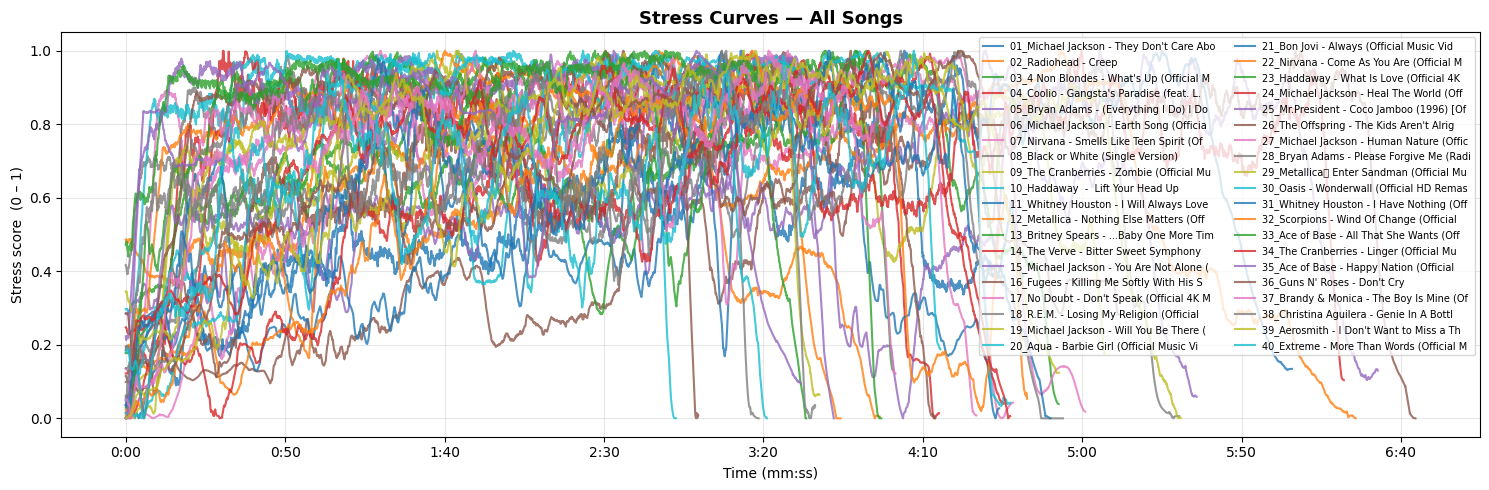

Batch plot saved → downloads/PL7DA3D097D6FDBC02/all_songs_stress.png


In [10]:
fig, ax = plt.subplots(figsize=(15, 5))

cmap = plt.get_cmap('tab10')
for idx, fpath in enumerate(audio_files):
    _cached = fpath.with_suffix('.features.npz').exists()
    _rms, _cent, _ons, _t = compute_features(fpath)
    _s  = 0.50 * norm01(_rms) + 0.25 * norm01(_cent) + 0.25 * norm01(_ons)
    _sf = int(SMOOTH_SEC * SR / HOP_LENGTH)
    _s  = norm01(uniform_filter1d(_s, size=_sf))
    ax.plot(_t, _s, linewidth=1.5, alpha=0.8,
            color=cmap(idx % 10), label=fpath.stem[:40])
    print(f'[{idx}] {"(cache)" if _cached else "(computed)"}  {fpath.name}')

ax.set_title('Stress Curves — All Songs', fontsize=13, fontweight='bold')
ax.set_ylabel('Stress score  (0 – 1)')
ax.set_xlabel('Time (mm:ss)')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(fmt_time))
ax.legend(fontsize=7, loc='upper right', ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
out_batch = DOWNLOAD_DIR / 'all_songs_stress.png'
plt.savefig(str(out_batch), dpi=150, bbox_inches='tight')
plt.show()
print(f'Batch plot saved → {out_batch}')

### Reading this chart

Each coloured line is one song's stress arc, smoothed to a 5-second window, from its first second to its last. Reading a line left to right shows how the overall energy — volume, brightness and rhythm speed combined — evolves throughout that track.

**Common patterns to look for:**

| Shape | What it means |
|---|---|
| Flat line | Consistent energy throughout — typical of background, ambient or minimalist music. |
| Rises then falls (arch) | Classic intro → chorus → outro structure common in pop and rock. |
| Multiple peaks | Several distinct choruses or bridges separated by quieter verses. |
| Starts high, stays high | High-energy track with little dynamic contrast — common in dance or metal. |
| Slow rise to the end | A "builder" — the arrangement keeps adding layers until the finale. |

**Comparing songs:** Lines clustered high on the chart are the most intense tracks in the playlist. Lines sitting low are the calmest. Songs whose curves overlap share a similar energy structure, even if they sound very different.

## Top 3 Most Stressed vs Top 3 Least Stressed

Compare the energy arcs of the most intense and the calmest songs in the playlist side by side.

  01_Michael Jackson - They Don't Care About Us       avg=0.499
  02_Radiohead - Creep                                avg=0.611
  03_4 Non Blondes - What's Up (Official Music Video  avg=0.686
  04_Coolio - Gangsta's Paradise (feat. L.V.) [Offic  avg=0.767
  05_Bryan Adams - (Everything I Do) I Do It For You  avg=0.635
  06_Michael Jackson - Earth Song (Official Video)    avg=0.527
  07_Nirvana - Smells Like Teen Spirit (Official Mus  avg=0.773
  08_Black or White (Single Version)                  avg=0.820
  09_The Cranberries - Zombie (Official Music Video)  avg=0.713
  10_Haddaway  -  Lift Your Head Up                   avg=0.789
  11_Whitney Houston - I Will Always Love You (Offic  avg=0.435
  12_Metallica - Nothing Else Matters (Official Musi  avg=0.593
  13_Britney Spears - ...Baby One More Time (Officia  avg=0.637
  14_The Verve - Bitter Sweet Symphony                avg=0.780
  15_Michael Jackson - You Are Not Alone (Official V  avg=0.584
  16_Fugees - Killing Me Softly With His

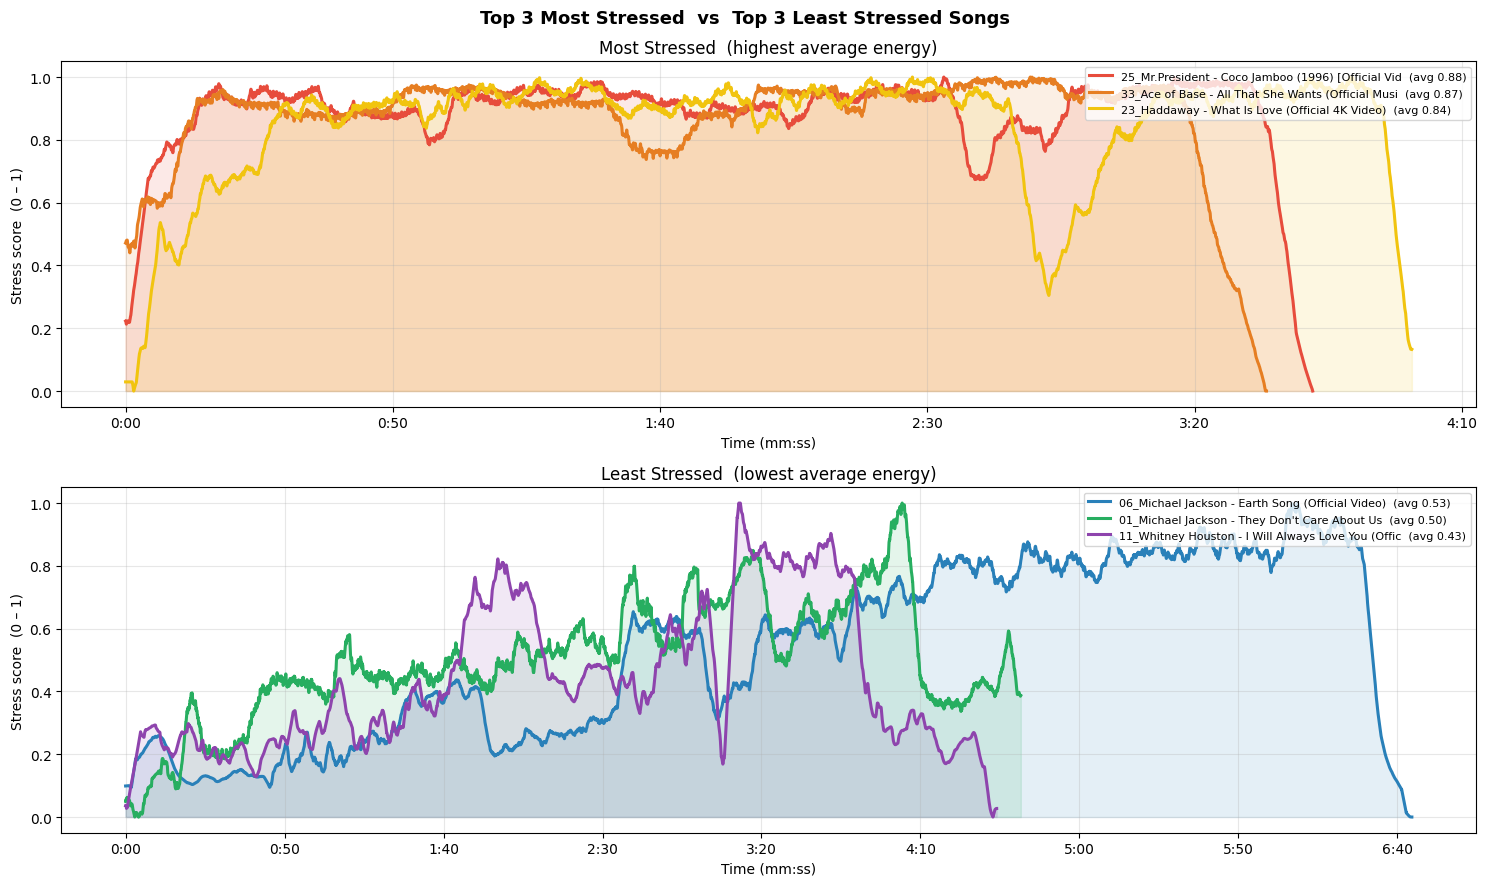

Chart saved → downloads/PL7DA3D097D6FDBC02/top3_vs_bottom3_stress.png


In [11]:
# ── Rank every song by its average smoothed stress score ─────────────────────
stress_means = {}
for fpath in audio_files:
    _rms, _cent, _ons, _t = compute_features(fpath)
    _s  = 0.50 * norm01(_rms) + 0.25 * norm01(_cent) + 0.25 * norm01(_ons)
    _sf = int(SMOOTH_SEC * SR / HOP_LENGTH)
    _s  = norm01(uniform_filter1d(_s, size=_sf))
    stress_means[fpath] = float(_s.mean())
    print(f'  {fpath.stem[:50]:<50}  avg={stress_means[fpath]:.3f}')

ranked  = sorted(stress_means, key=stress_means.get, reverse=True)
top3    = ranked[:3]
bottom3 = ranked[-3:]

print('\nTop 3 most stressed:')
for f in top3:    print(f'  {stress_means[f]:.3f}  {f.stem}')
print('Top 3 least stressed:')
for f in bottom3: print(f'  {stress_means[f]:.3f}  {f.stem}')

# ── Plot ──────────────────────────────────────────────────────────────────────
colors_hot  = ['#e74c3c', '#e67e22', '#f1c40f']
colors_cool = ['#2980b9', '#27ae60', '#8e44ad']

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=False)
fig.suptitle('Top 3 Most Stressed  vs  Top 3 Least Stressed Songs',
             fontsize=13, fontweight='bold')

for ax, group, colors, title in [
    (axes[0], top3,    colors_hot,  'Most Stressed  (highest average energy)'),
    (axes[1], bottom3, colors_cool, 'Least Stressed  (lowest average energy)'),
]:
    for fpath, color in zip(group, colors):
        _rms, _cent, _ons, _t = compute_features(fpath)
        _s  = 0.50 * norm01(_rms) + 0.25 * norm01(_cent) + 0.25 * norm01(_ons)
        _sf = int(SMOOTH_SEC * SR / HOP_LENGTH)
        _s  = norm01(uniform_filter1d(_s, size=_sf))
        avg = stress_means[fpath]
        ax.fill_between(_t, _s, alpha=0.12, color=color)
        ax.plot(_t, _s, linewidth=2.2, color=color,
                label=f'{fpath.stem[:50]}  (avg {avg:.2f})')
    ax.set_title(title)
    ax.set_ylabel('Stress score  (0 – 1)')
    ax.set_xlabel('Time (mm:ss)')
    ax.set_ylim(-0.05, 1.05)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(fmt_time))
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
out_cmp = DOWNLOAD_DIR / 'top3_vs_bottom3_stress.png'
plt.savefig(str(out_cmp), dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved → {out_cmp}')

### Reading this chart

Songs are ranked by their **average stress score** — the arithmetic mean of the smoothed stress curve across the full track duration. This single number captures how energetic a song is *on average*, ignoring when the peaks occur.

**How the ranking is calculated:**
1. Extract Music Volume, Instrumental Brightness and Rhythm Speed for each song.
2. Combine them into a per-frame stress score (50 % / 25 % / 25 % weights).
3. Smooth over a 5-second window to remove beat-level noise.
4. Take the mean of all values → one number per song.
5. Sort descending; take the first 3 (most stressed) and last 3 (least stressed).

---

**Top panel — Most Stressed (warm colours: red, orange, yellow)**
These are the most intense tracks in the playlist. They tend to be loud throughout, with prominent high-pitched instruments (bright guitars, synths, sharp snare hits) and fast, dense rhythmic activity. Expect energetic pop, rock, dance or hip-hop tracks.

**Bottom panel — Least Stressed (cool colours: blue, green, purple)**
These are the calmest, most subdued tracks. They tend to feature slower tempos, softer dynamics, warmer timbres (acoustic guitar, piano, low strings) and fewer simultaneous notes at any given moment. Expect ballads, acoustic pieces or slow R&B.

**The legend** shows each song's title and its average score in parentheses. A score near 1 = intense from start to finish. A score near 0 = consistently quiet and gentle. The shape of the curve still matters: two songs can share the same average but one may spike dramatically at the chorus while the other stays flat.